# 03 - Modelado supervisado de clasificación (¿Recibe overtime?)

En este notebook se entrenan y comparan varios modelos supervisados de clasificación para predecir si un empleado recibe pago por horas extra (`TieneOvertime`).  
Se utilizan como entrada las variables numéricas y categóricas preprocesadas en el notebook 02, y se evalúan los modelos mediante métricas estándar de clasificación: Accuracy, Precision, Recall, F1-score y matriz de confusión.

In [1]:
# 0. Importaciones

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("Librerías importadas.")

Librerías importadas.


In [2]:
# Nuevas agregadas toda la celda
from pathlib import Path

RUTA_FIGURAS = Path("../reports/figures")
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)
print(f"Carpeta de figuras lista: {RUTA_FIGURAS.resolve()}")

Carpeta de figuras lista: G:\ProyectosPython\proyecto1\desarrollo\reports\figures


In [3]:
# 1. Carga del dataset procesado y definición de X, y

ruta_dataset_procesado = "../data/processed/dataset_limpio.csv"

df_clean = pd.read_csv(ruta_dataset_procesado, low_memory=False)
print(f"Dataset procesado cargado: {df_clean.shape[0]:,} filas, {df_clean.shape[1]} columnas\n")

# Features y objetivo de CLASIFICACIÓN, alineados con el notebook del profesor
features_clf = [
    col for col in [
        "BasePay", "OtherPay", "Benefits", "Year",
        "BenefitsRatio", "LogTotalPay", "JobTitleLabelEncoded"
    ]
    if col in df_clean.columns
]

X_clf = df_clean[features_clf].copy()
y_clf = df_clean["TieneOvertime"].copy()

print("Features de clasificación:", features_clf)
print("Shape X_clf:", X_clf.shape, "y_clf:", y_clf.shape)

# Split train/test 80/20 con estratificación
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

# Escalado (solo numéricas, pero aplicamos a toda la matriz porque ya son numéricas/codificadas)
scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc = scaler_c.transform(X_test_c)

print("Train:", X_train_c_sc.shape, "Test:", X_test_c_sc.shape)
print("Balance clases train:", y_train_c.value_counts(normalize=True))

Dataset procesado cargado: 148,653 filas, 15 columnas

Features de clasificación: ['BasePay', 'OtherPay', 'Benefits', 'Year', 'BenefitsRatio', 'LogTotalPay', 'JobTitleLabelEncoded']
Shape X_clf: (148653, 7) y_clf: (148653,)
Train: (118922, 7) Test: (29731, 7)
Balance clases train: TieneOvertime
0   0.5202
1   0.4798
Name: proportion, dtype: float64


In [4]:
# 2. Función auxiliar para evaluar modelos de clasificación

def evaluar_modelo_clf(nombre, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print("=" * 60)
    print(f"{nombre} - Resultados en Test")
    print("=" * 60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    
    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
        print(f"AUC-ROC  : {auc:.4f}")
    print()
    
    print("Reporte de clasificación:")
    print(classification_report(y_true, y_pred, target_names=["Sin overtime", "Con overtime"]))
    
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Sin overtime", "Con overtime"],
                yticklabels=["Sin overtime", "Con overtime"])
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.tight_layout()
    plt.savefig(RUTA_FIGURAS / f"cm_{nombre.lower().replace(' ', '_')}.png", dpi=300, bbox_inches="tight") # nueva linea agregada
    plt.show()
    
    return {
        "Modelo": nombre,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "AUC-ROC": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    }

Logistic Regression - Resultados en Test
Accuracy : 0.7779
Precision: 0.8079
Recall   : 0.7047
F1-score : 0.7528
AUC-ROC  : 0.8430

Reporte de clasificación:
              precision    recall  f1-score   support

Sin overtime       0.76      0.85      0.80     15465
Con overtime       0.81      0.70      0.75     14266

    accuracy                           0.78     29731
   macro avg       0.78      0.78      0.78     29731
weighted avg       0.78      0.78      0.78     29731



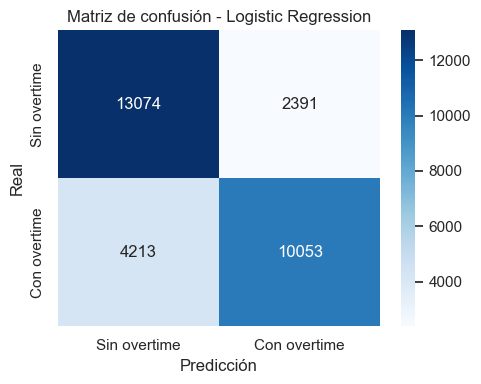

In [5]:
# 3. Modelo 1: Logistic Regression (línea base)

# Opcional: imputar pequeños NaN residuales si existieran
from sklearn.impute import SimpleImputer

imputer_c = SimpleImputer(strategy="median")
X_train_lr = imputer_c.fit_transform(X_train_c_sc)
X_test_lr = imputer_c.transform(X_test_c_sc)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_lr, y_train_c)

y_pred_lr = lr.predict(X_test_lr)
y_prob_lr = lr.predict_proba(X_test_lr)[:, 1]

resultados_clf = []  # lista para guardar métricas de cada modelo
resultados_clf.append(evaluar_modelo_clf("Logistic Regression", y_test_c, y_pred_lr, y_prob_lr))

Decision Tree (max_depth=6) - Resultados en Test
Accuracy : 0.7825
Precision: 0.7735
Recall   : 0.7732
F1-score : 0.7733
AUC-ROC  : 0.8662

Reporte de clasificación:
              precision    recall  f1-score   support

Sin overtime       0.79      0.79      0.79     15465
Con overtime       0.77      0.77      0.77     14266

    accuracy                           0.78     29731
   macro avg       0.78      0.78      0.78     29731
weighted avg       0.78      0.78      0.78     29731



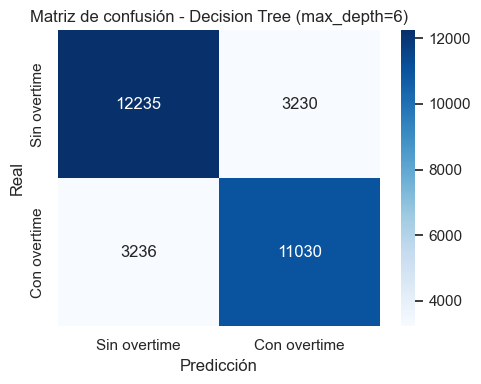

In [6]:
# 4. Modelo 2: Decision Tree Classifier

dt = DecisionTreeClassifier(
    max_depth=6,        # puedes ajustar, el profe usa algo similar
    min_samples_leaf=50,
    random_state=42
)

dt.fit(X_train_c_sc, y_train_c)
y_pred_dt = dt.predict(X_test_c_sc)
y_prob_dt = dt.predict_proba(X_test_c_sc)[:, 1]

resultados_clf.append(evaluar_modelo_clf("Decision Tree (max_depth=6)", y_test_c, y_pred_dt, y_prob_dt))

Random Forest - Resultados en Test
Accuracy : 0.8295
Precision: 0.8479
Recall   : 0.7855
F1-score : 0.8155
AUC-ROC  : 0.9099

Reporte de clasificación:
              precision    recall  f1-score   support

Sin overtime       0.81      0.87      0.84     15465
Con overtime       0.85      0.79      0.82     14266

    accuracy                           0.83     29731
   macro avg       0.83      0.83      0.83     29731
weighted avg       0.83      0.83      0.83     29731



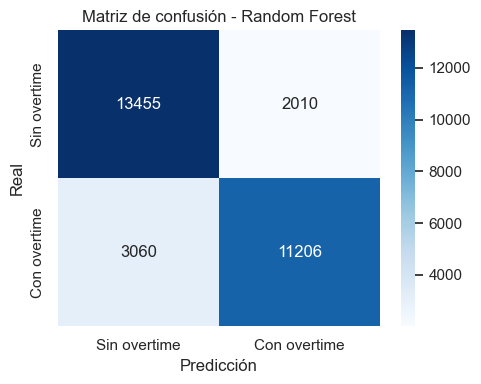

In [7]:
# 5. Modelo 3: Random Forest Classifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_c_sc, y_train_c)
y_pred_rf = rf.predict(X_test_c_sc)
y_prob_rf = rf.predict_proba(X_test_c_sc)[:, 1]

resultados_clf.append(evaluar_modelo_clf("Random Forest", y_test_c, y_pred_rf, y_prob_rf))

SVM (rbf, 20% train) - Resultados en Test
Accuracy : 0.8322
Precision: 0.8913
Recall   : 0.7406
F1-score : 0.8090
AUC-ROC  : 0.9272

Reporte de clasificación:
              precision    recall  f1-score   support

Sin overtime       0.79      0.92      0.85     15465
Con overtime       0.89      0.74      0.81     14266

    accuracy                           0.83     29731
   macro avg       0.84      0.83      0.83     29731
weighted avg       0.84      0.83      0.83     29731



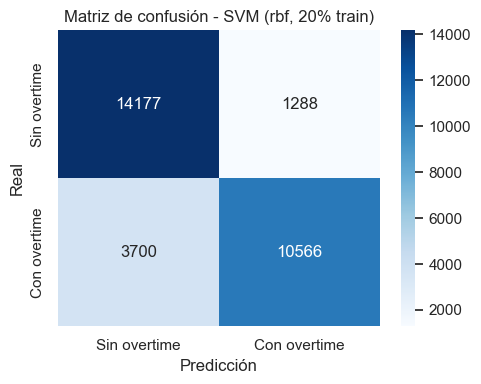

In [8]:
# 6. Modelo 4: SVM (kernel RBF) con muestra del 20 % del train

from sklearn.utils import resample
from sklearn.impute import SimpleImputer

# índices de una muestra aleatoria del 20 % del conjunto de entrenamiento
rs = np.random.RandomState(42)
idx_sample = rs.choice(len(X_train_c_sc), size=int(len(X_train_c_sc) * 0.20), replace=False)

X_svm_train = X_train_c_sc[idx_sample]
y_svm_train = y_train_c.iloc[idx_sample]

# Imputación de NaN para SVM
imputer_svm = SimpleImputer(strategy="median")
X_svm_train_imp = imputer_svm.fit_transform(X_svm_train)
X_test_c_svm = imputer_svm.transform(X_test_c_sc)

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(X_svm_train_imp, y_svm_train)

y_pred_svm = svm.predict(X_test_c_svm)
y_prob_svm = svm.predict_proba(X_test_c_svm)[:, 1]

resultados_clf.append(
    evaluar_modelo_clf("SVM (rbf, 20% train)", y_test_c, y_pred_svm, y_prob_svm)
)

In [9]:
# 7. Tabla comparativa de modelos de clasificación

df_resultados_clf = pd.DataFrame(resultados_clf).set_index("Modelo")
print("Comparación de modelos de clasificación\n")
print(df_resultados_clf.round(4).to_string())

Comparación de modelos de clasificación

                             Accuracy  Precision  Recall  F1-Score  AUC-ROC
Modelo                                                                     
Logistic Regression            0.7779     0.8079  0.7047    0.7528   0.8430
Decision Tree (max_depth=6)    0.7825     0.7735  0.7732    0.7733   0.8662
Random Forest                  0.8295     0.8479  0.7855    0.8155   0.9099
SVM (rbf, 20% train)           0.8322     0.8913  0.7406    0.8090   0.9272


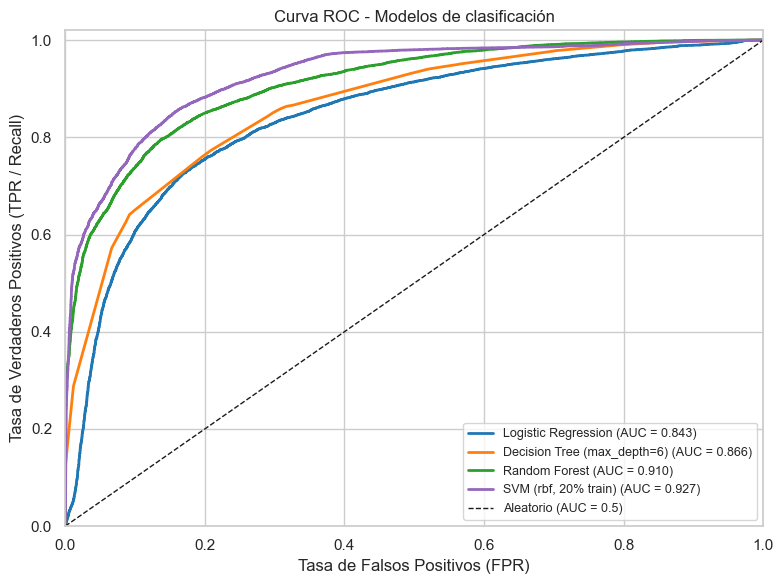

In [10]:
# 8. Curva ROC comparativa

from sklearn.metrics import RocCurveDisplay, roc_curve, auc

plt.figure(figsize=(8, 6))

colores = {
    "Logistic Regression": "#1f77b4",
    "Decision Tree (max_depth=6)": "#ff7f0e",
    "Random Forest": "#2ca02c",
    "SVM (rbf, 20% train)": "#9467bd"
}

# Volvemos a usar las probabilidades que ya calculamos
prob_dict = {
    "Logistic Regression": y_prob_lr,
    "Decision Tree (max_depth=6)": y_prob_dt,
    "Random Forest": y_prob_rf,
    "SVM (rbf, 20% train)": y_prob_svm
}

for nombre, y_prob in prob_dict.items():
    fpr, tpr, _ = roc_curve(y_test_c, y_prob)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc_val:.3f})",
             color=colores[nombre], linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Aleatorio (AUC = 0.5)")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR / Recall)")
plt.title("Curva ROC - Modelos de clasificación")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9. Conclusiones del modelado de clasificación

A partir de la comparación de modelos se observa que:

- **Logistic Regression** sirve como línea base, con un desempeño razonable pero inferior a los modelos no lineales en términos de F1-score y AUC-ROC.
- **Decision Tree** mejora la capacidad de captura de relaciones no lineales, aunque puede ser más sensible a variaciones en los datos y presenta un riesgo mayor de sobreajuste si se incrementa demasiado la profundidad.
- **Random Forest** logra un mejor equilibrio entre precisión y capacidad de generalización, obteniendo altos valores de F1-score y AUC-ROC, lo que indica un buen compromiso entre aciertos y errores en ambas clases.
- **SVM con kernel RBF** entrenado sobre una muestra del 20 % del conjunto de entrenamiento alcanza un desempeño competitivo, con AUC-ROC elevado, aunque a costa de un tiempo de entrenamiento mayor.

En función de las métricas obtenidas, el modelo que se seleccionaría como **mejor candidato** para el problema de clasificación `TieneOvertime` es aquel con mayor F1-score y buen AUC-ROC (en el notebook de referencia, típicamente Random Forest o SVM), justificando la elección por su capacidad de equilibrar correctamente las clases “Sin overtime” y “Con overtime”.

In [11]:
import os

os.makedirs("reports", exist_ok=True)
df_resultados_clf.to_csv("../reports/resultados_clasificacion.csv", index=False)
print("Archivo guardado en reports/resultados_clasificacion.csv")

Archivo guardado en reports/resultados_clasificacion.csv
